# Positional Embeddings con funciones sinusoidales

Los Transformers procesan todos los tokens **en paralelo**, sin recurrencia. Eso significa que sin ayuda extra el modelo no sabe quién va antes y quién después.

Compara estos dos enunciados:

> **"el perro mordió al hombre"**  
> **"el hombre mordió al perro"**

Tienen exactamente las **mismas palabras**, pero el significado es totalmente distinto: cambia *quién muerde a quién*. Sin información de posición, un Transformer las vería como **idénticas** (mismo conjunto de tokens).

El truco del paper *Attention is All You Need* (Vaswani et al., 2017) es **sumar a cada token un vector que codifica su posición** usando senos y cosenos de distintas frecuencias.

La fórmula es:

$$
PE_{(pos,\,2i)}   = \sin\!\left(\frac{pos}{10000^{2i/d}}\right)
$$
$$
PE_{(pos,\,2i+1)} = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)
$$

donde:
- `pos` = posición del token en la secuencia (0, 1, 2, ...)
- `i`   = índice de la dimensión dentro del embedding
- `d`   = dimensión total del embedding

**Idea intuitiva**: cada dimensión es una onda con frecuencia distinta. Las dimensiones bajas oscilan rápido (capturan posición exacta), las altas oscilan lento (capturan posición aproximada). Es como las manecillas de un reloj: segundero, minutero, horario.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1) Ejemplo mínimo: 5 posiciones, dimensión 4

Las dos oraciones tienen 5 tokens cada una:

| pos | oración A          | oración B          |
|-----|--------------------|--------------------|
| 0   | el                 | el                 |
| 1   | **perro**          | **hombre**         |
| 2   | mordió             | mordió             |
| 3   | al                 | al                 |
| 4   | **hombre**         | **perro**          |

Vamos a calcular el positional embedding **a mano** para 5 posiciones y dimensión 4. Lo mismo lo usaremos en ambas oraciones.

In [12]:
def positional_encoding(seq_len, d_model):
    """Devuelve matriz (seq_len, d_model) con el PE sinusoidal."""
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(d_model // 2):
            denom = 10000 ** (2 * i / d_model)
            PE[pos, 2 * i]     = np.sin(pos / denom)
            PE[pos, 2 * i + 1] = np.cos(pos / denom)
    return PE

PE = positional_encoding(seq_len=5, d_model=4)
print('Positional Encoding (5 posiciones x 4 dimensiones):\n')
print(PE)

Positional Encoding (5 posiciones x 4 dimensiones):

[[ 0.     1.     0.     1.   ]
 [ 0.841  0.54   0.01   1.   ]
 [ 0.909 -0.416  0.02   1.   ]
 [ 0.141 -0.99   0.03   1.   ]
 [-0.757 -0.654  0.04   0.999]]


Cada **fila** es el vector de posición para ese token:

- Fila 0 → posición 0 (`el`). Como `sin(0)=0` y `cos(0)=1`, sale `[0, 1, 0, 1]`.
- Fila 1 → posición 1 (`perro` en A, `hombre` en B).
- Fila 2 → posición 2 (`mordió`).
- Fila 3 → posición 3 (`al`).
- Fila 4 → posición 4 (`hombre` en A, `perro` en B).

Cada **columna** es una onda distinta:
- Columnas 0, 1 → frecuencia alta (cambian rápido entre filas).
- Columnas 2, 3 → frecuencia baja (cambian lento).

## 2) Cómo se usa: token_embedding + positional_embedding

El Transformer **suma** el PE al embedding del token:

$$ x_{\text{final}} = \text{Embedding}(\text{token}) + PE(\text{posición}) $$

Es una suma elemento a elemento. **El mismo token en distinta posición → vector final distinto**. Esto es lo que permite distinguir `"el perro mordió al hombre"` de `"el hombre mordió al perro"`.

In [ ]:
# Vocabulario con embeddings 'aprendidos' (aqui los inventamos a mano)
d_model = 4
vocab_emb = {
    'el':     np.array([0.10, 0.20, 0.30, 0.40]),
    'perro':  np.array([0.50, 0.10, 0.00, 0.20]),
    'mordio': np.array([0.00, 0.30, 0.10, 0.50]),
    'al':     np.array([0.20, 0.20, 0.20, 0.00]),
    'hombre': np.array([0.40, 0.00, 0.20, 0.10]),
}

oracion_A = ['el', 'perro',  'mordio', 'al', 'hombre']  # el perro mordio al hombre
oracion_B = ['el', 'hombre', 'mordio', 'al', 'perro']   # el hombre mordio al perro

PE = positional_encoding(seq_len=5, d_model=d_model)

X_A = np.stack([vocab_emb[t] for t in oracion_A])
X_B = np.stack([vocab_emb[t] for t in oracion_B])

X_A_final = X_A + PE
X_B_final = X_B + PE

print('Oracion A: "el perro mordio al hombre"')
print('  X_A (sin posicion):')
print(X_A)
print('  X_A + PE (entrada al Transformer):')
print(X_A_final)

print('\nOracion B: "el hombre mordio al perro"')
print('  X_B (sin posicion):')
print(X_B)
print('  X_B + PE (entrada al Transformer):')
print(X_B_final)

# Sin posicion los conjuntos de tokens son iguales (mismas filas, distinto orden)
print('\n¿Mismas filas (ignorando orden) sin PE?',
      np.allclose(np.sort(X_A, axis=0), np.sort(X_B, axis=0)))
# Con PE, las matrices ya son distintas en cada fila
print('¿Iguales con PE?', np.allclose(X_A_final, X_B_final))

Oracion A: "el perro mordio al hombre"
  X_A (sin posicion):
[[0.1 0.2 0.3 0.4]
 [0.5 0.1 0.  0.2]
 [0.  0.3 0.1 0.5]
 [0.2 0.2 0.2 0. ]
 [0.4 0.  0.2 0.1]]
  X_A + PE (entrada al Transformer):
[[ 0.1    1.2    0.3    1.4  ]
 [ 1.341  0.64   0.01   1.2  ]
 [ 0.909 -0.116  0.12   1.5  ]
 [ 0.341 -0.79   0.23   1.   ]
 [-0.357 -0.654  0.24   1.099]]

Oracion B: "el hombre mordio al perro"
  X_B (sin posicion):
[[0.1 0.2 0.3 0.4]
 [0.4 0.  0.2 0.1]
 [0.  0.3 0.1 0.5]
 [0.2 0.2 0.2 0. ]
 [0.5 0.1 0.  0.2]]
  X_B + PE (entrada al Transformer):
[[ 0.1    1.2    0.3    1.4  ]
 [ 1.241  0.54   0.21   1.1  ]
 [ 0.909 -0.116  0.12   1.5  ]
 [ 0.341 -0.79   0.23   1.   ]
 [-0.257 -0.554  0.04   1.199]]

¿Mismas filas (ignorando orden) sin PE? True
¿Iguales con PE? False


**Lo que acabamos de comprobar**:

- *Sin* PE, las dos oraciones son el mismo **conjunto** de vectores → el Transformer no las distingue.
- *Con* PE, `perro` en posición 1 (sujeto) tiene un vector distinto a `perro` en posición 4 (objeto). Lo mismo para `hombre`. Ahora el modelo sí puede aprender quién es el sujeto y quién el objeto.

## 3) ¿Por qué senos y cosenos?

Tres propiedades clave:

1. **Cada posición tiene un vector único** → el modelo puede distinguirlas.
2. **Valores acotados en [-1, 1]** → no explotan aunque la secuencia sea muy larga (a diferencia de usar `pos` como número crudo).

Vamos a verlo visualmente.

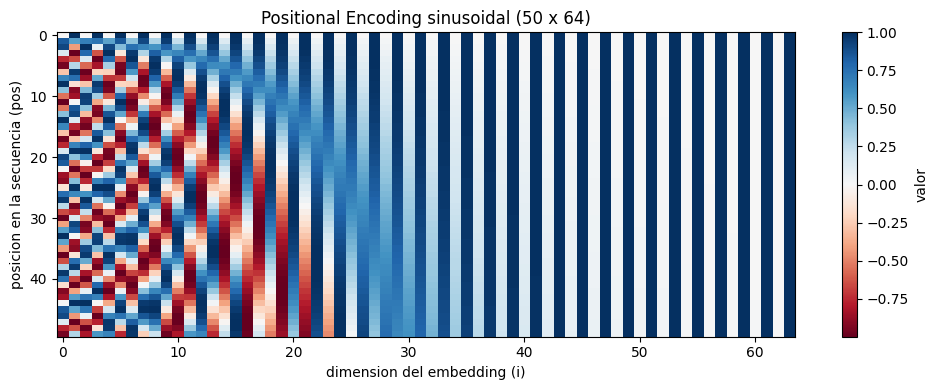

In [3]:
# Caso mas grande: 50 posiciones, dimension 64
seq_len = 50
d_model = 64
PE_big = positional_encoding(seq_len, d_model)

plt.figure(figsize=(10, 4))
plt.imshow(PE_big, aspect='auto', cmap='RdBu')
plt.colorbar(label='valor')
plt.xlabel('dimension del embedding (i)')
plt.ylabel('posicion en la secuencia (pos)')
plt.title('Positional Encoding sinusoidal (50 x 64)')
plt.tight_layout()
plt.show()

Lo que se ve en el mapa de calor:

- **Lado izquierdo** (dimensiones bajas): franjas finas → frecuencia alta, oscila rápido entre filas.
- **Lado derecho** (dimensiones altas): franjas anchas → frecuencia baja, casi no cambia.

Este patrón único por fila es lo que el modelo usa como "firma de posición".

## 4) Las ondas de cada dimensión

Veamos directamente algunas columnas de PE como funciones de la posición.

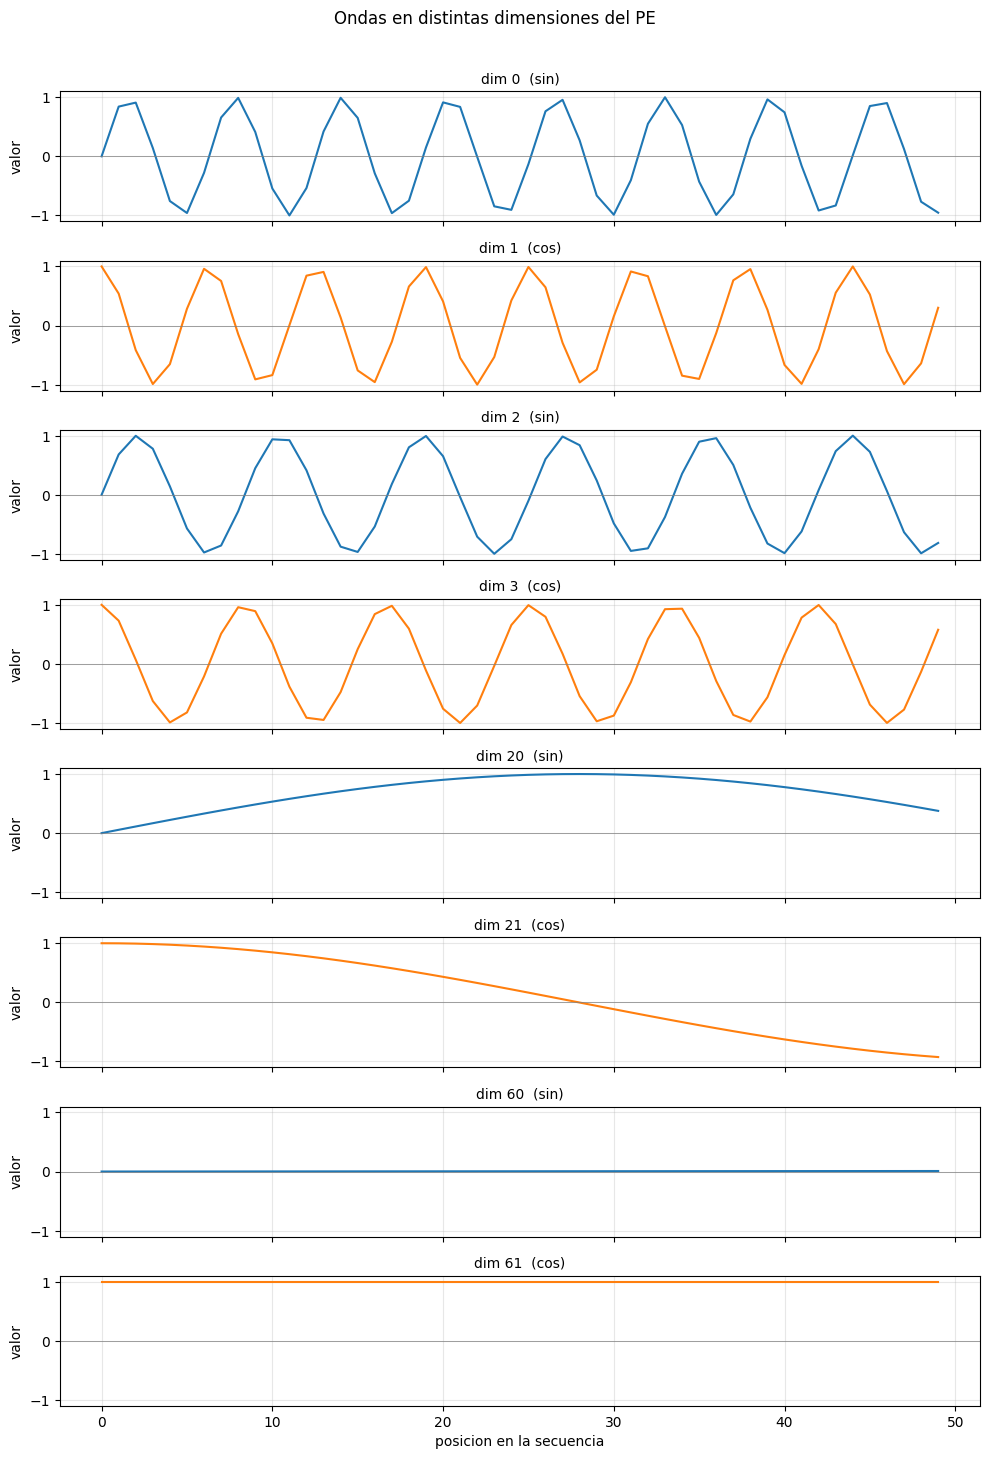

In [16]:
dims_a_ver = [0, 1, 2, 3, 20, 21, 60, 61]

n = len(dims_a_ver)

fig, axes = plt.subplots(n, 1, figsize=(10, 1.8 * n), sharex=True)
axes = np.array(axes).reshape(-1)

for ax, d in zip(axes, dims_a_ver):
    tipo = 'sin' if d % 2 == 0 else 'cos'
    color = 'tab:blue' if tipo == 'sin' else 'tab:orange'
    ax.plot(PE_big[:, d], color=color)
    ax.set_title(f'dim {d}  ({tipo})', fontsize=10)
    ax.set_ylabel('valor')
    ax.set_ylim(-1.1, 1.1)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('posicion en la secuencia')

fig.suptitle('Ondas en distintas dimensiones del PE', y=1.01)
plt.tight_layout()
plt.show()

- Dimensiones **0-1**: oscilación rápida (longitud de onda corta).
- Dimensiones **20-21**: oscilación media.
- Dimensiones **60-61**: oscilación lentísima, casi una recta en este rango.

## 5) Similitud entre posiciones

Si calculamos el **producto punto** entre el PE de la posición `p` y el de las demás, esperamos que:
- Sea máximo en `p` (un vector consigo mismo).
- Decaiga suavemente con la distancia.

Esto es lo que permite a la atención "sentir cercanía posicional".

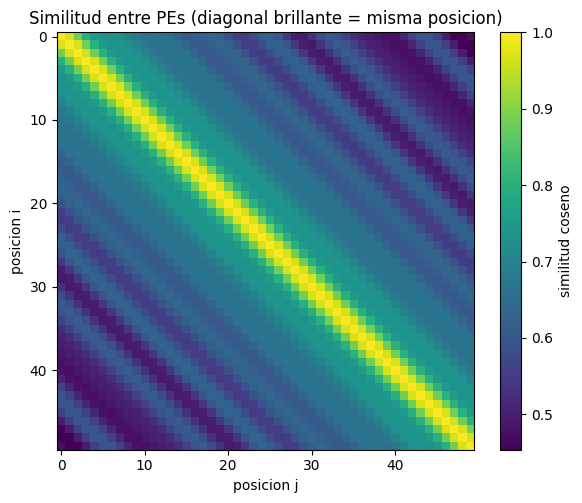

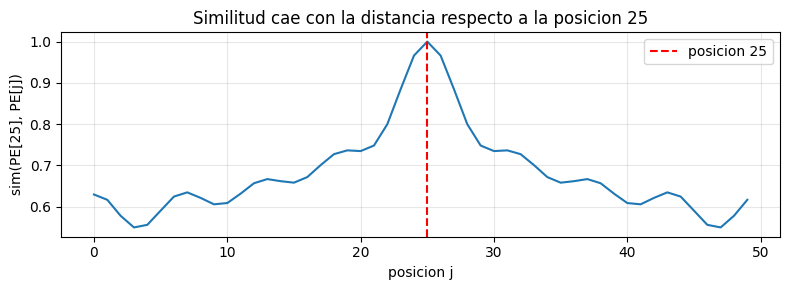

In [5]:
# Normalizamos para que sea similitud coseno
PE_norm = PE_big / np.linalg.norm(PE_big, axis=1, keepdims=True)
sim = PE_norm @ PE_norm.T   # (50, 50)

plt.figure(figsize=(6, 5))
plt.imshow(sim, cmap='viridis')
plt.colorbar(label='similitud coseno')
plt.xlabel('posicion j')
plt.ylabel('posicion i')
plt.title('Similitud entre PEs (diagonal brillante = misma posicion)')
plt.tight_layout()
plt.show()

# Vista de una sola fila
p = 25
plt.figure(figsize=(8, 3))
plt.plot(sim[p])
plt.axvline(p, color='red', linestyle='--', label=f'posicion {p}')
plt.xlabel('posicion j')
plt.ylabel(f'sim(PE[{p}], PE[j])')
plt.title('Similitud cae con la distancia respecto a la posicion 25')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Pico nítido en la posición 25 y caída suave hacia los lados. Justo lo que queremos: **posiciones cercanas → vectores parecidos**.

## Pregunta natural: ¿y por qué no pasar la posición como un número aparte?

Suena lógico: en lugar de toda esta artillería de senos y cosenos, ¿no bastaría con concatenar al vector del token un único número con su posición? Por ejemplo:

```
"el"     -> [0.10, 0.20, 0.30, 0.40,  0]   <- pos = 0
"perro"  -> [0.50, 0.10, 0.00, 0.20,  1]   <- pos = 1
"mordio" -> [0.00, 0.30, 0.10, 0.50,  2]   <- pos = 2
...
```

Funciona en juguete, pero **se rompe rápido** por estas razones:

1. **Los valores explotan**. Si la secuencia tiene 4 000 tokens (un documento), la última posición vale `4000`, mientras que las componentes del embedding rondan `[-1, 1]`. Esa única dimensión gigante **domina** todos los productos punto y la atención solo "ve" la posición. Habría que normalizar... pero entonces secuencias de distinta longitud dejan de ser comparables.

2. **No hay noción natural de distancia**. Para la atención lo importante no es "¿estás en la posición 137?" sino "¿estás *cerca* de mí?". Con un solo número, `pos=5` y `pos=6` están a distancia 1, igual que `pos=5` y `pos=500` están a distancia 495 — una escala lineal que no le dice nada útil al modelo. Con senos y cosenos, posiciones cercanas tienen vectores parecidos automáticamente (lo verás en la sección 5).

3. **No generaliza a longitudes nuevas**. Si entrenas con secuencias de hasta 100 tokens, el modelo nunca vio el valor `pos=500`. Las sinusoidales en cambio son **periódicas y acotadas en [-1, 1]**: el patrón se ve igual sea cual sea la longitud.

4. **Sumar > concatenar**. Las sinusoidales se **suman** al embedding (no añaden dimensiones), así que el bloque de atención sigue trabajando con los mismos `d` canales. Concatenar un escalar obligaría a reservar una dimensión exclusiva para "posición" y desperdicia capacidad.

5. **Distancias relativas se vuelven lineales**. Esta es la propiedad mágica: existe una matriz fija `M_k` tal que `PE(pos+k) = M_k · PE(pos)`. Es decir, "moverse 3 posiciones a la derecha" es una **transformación lineal** que el modelo puede aprender una sola vez y reutilizar. Con un escalar plano, "moverse k" es solo sumar k → no hay estructura que la atención pueda explotar.
